In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_excel("../data/WHR26_Data_Figure_2.1.xlsx")

df.head()

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 2116
Columns: 13


In [4]:
df.columns

Index(['Year', 'Rank', 'Country name', 'Life evaluation (3-year average)',
       'Lower whisker', 'Upper whisker', 'Explained by: Log GDP per capita',
       'Explained by: Social support', 'Explained by: Healthy life expectancy',
       'Explained by: Freedom to make life choices',
       'Explained by: Generosity', 'Explained by: Perceptions of corruption',
       'Dystopia + residual'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Year                                        2116 non-null   int64  
 1   Rank                                        2116 non-null   int64  
 2   Country name                                2116 non-null   str    
 3   Life evaluation (3-year average)            2116 non-null   float64
 4   Lower whisker                               1022 non-null   float64
 5   Upper whisker                               1022 non-null   float64
 6   Explained by: Log GDP per capita            1019 non-null   float64
 7   Explained by: Social support                1019 non-null   float64
 8   Explained by: Healthy life expectancy       1016 non-null   float64
 9   Explained by: Freedom to make life choices  1017 non-null   float64
 10  Explained by: Generosit

In [6]:
df.isnull().sum()

Year                                             0
Rank                                             0
Country name                                     0
Life evaluation (3-year average)                 0
Lower whisker                                 1094
Upper whisker                                 1094
Explained by: Log GDP per capita              1097
Explained by: Social support                  1097
Explained by: Healthy life expectancy         1100
Explained by: Freedom to make life choices    1099
Explained by: Generosity                      1097
Explained by: Perceptions of corruption       1098
Dystopia + residual                           1103
dtype: int64

In [7]:
df.describe()

,Year,Rank,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
count,2116.000000,2116.000000,2116.000000,1022.000000,1022.000000,1019.000000,1019.000000,1016.000000,1017.000000,1019.000000,1018.000000,1013.000000
mean,2018.220227,76.190926,5.465655,5.436091,5.664733,1.265670,1.096746,0.553435,0.609465,0.147343,0.144911,1.736935
std,4.249844,43.845101,1.123870,1.140959,1.107424,0.463823,0.357642,0.229980,0.212070,0.084335,0.118803,0.657497
min,2011.000000,1.000000,1.364000,1.301000,1.427000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.295000
25%,2015.000000,38.000000,4.604750,4.619707,4.867750,0.944000,0.865000,0.389750,0.471000,0.088000,0.063156,1.305000
50%,2018.000000,76.000000,5.480000,5.592631,5.812000,1.304000,1.140119,0.560500,0.602000,0.134000,0.113000,1.765000
75%,2022.000000,114.000000,6.321250,6.290110,6.486500,1.636000,1.382000,0.712325,0.735000,0.195477,0.181330,2.178000
max,2025.000000,158.000000,7.856000,7.780000,7.904000,2.209000,1.840000,1.238000,1.147000,0.569814,0.587000,3.482000


In [8]:
print("Total Countries:", df["Country name"].nunique())

Total Countries: 168


In [9]:
top10 = df.sort_values(
    "Life evaluation (3-year average)",
    ascending=False
).head(10)

top10[["Country name",
       "Life evaluation (3-year average)"]]

,Country name,Life evaluation (3-year average)
1960,Denmark,7.8560
720,Finland,7.8420
574,Finland,7.8210
869,Finland,7.8087
437,Finland,7.8040
1022,Finland,7.7690
0,Finland,7.7640
294,Finland,7.7410
147,Finland,7.7360
1804,Denmark,7.6930


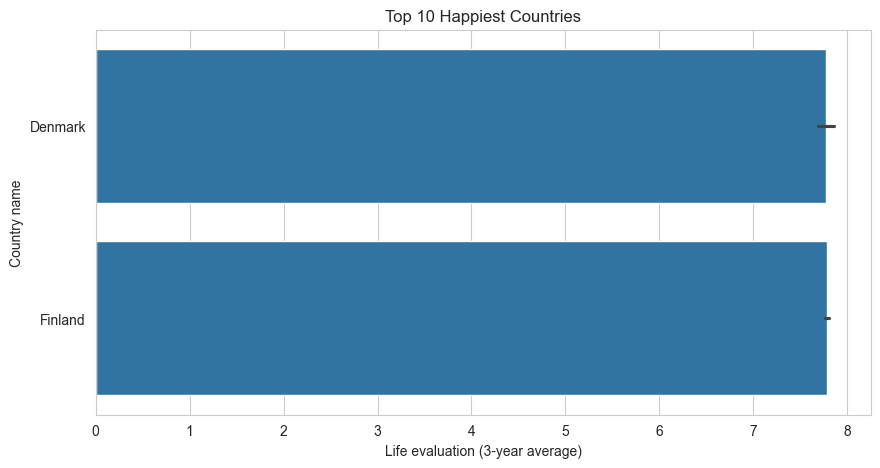

In [10]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=top10,
    x="Life evaluation (3-year average)",
    y="Country name"
)

plt.title("Top 10 Happiest Countries")
plt.show()

In [11]:
bottom10 = df.sort_values(
    "Life evaluation (3-year average)"
).head(10)

bottom10[["Country name",
          "Life evaluation (3-year average)"]]

,Country name,Life evaluation (3-year average)
293,Afghanistan,1.3640
146,Afghanistan,1.4460
436,Afghanistan,1.7210
573,Afghanistan,1.8590
572,Lebanon,2.3920
719,Afghanistan,2.4040
868,Afghanistan,2.5230
1021,Afghanistan,2.5669
1488,Central African Republic,2.6930
435,Lebanon,2.7070


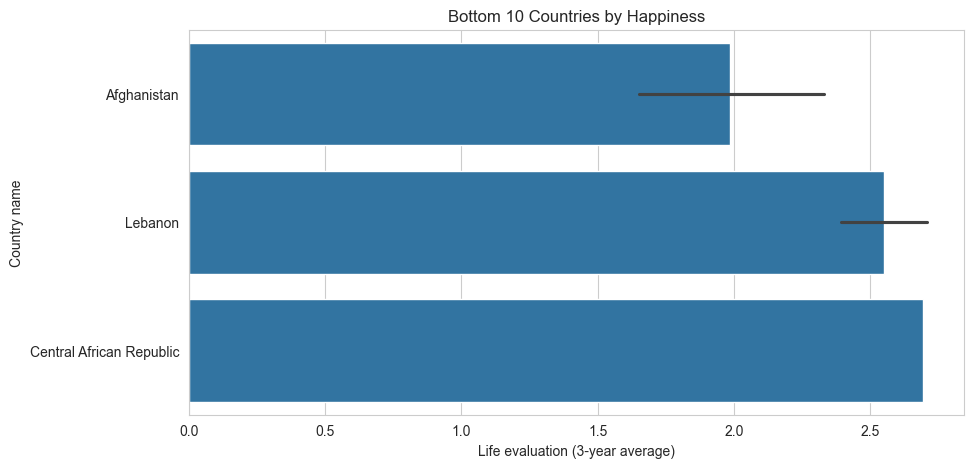

In [12]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=bottom10,
    x="Life evaluation (3-year average)",
    y="Country name"
)

plt.title("Bottom 10 Countries by Happiness")
plt.show()

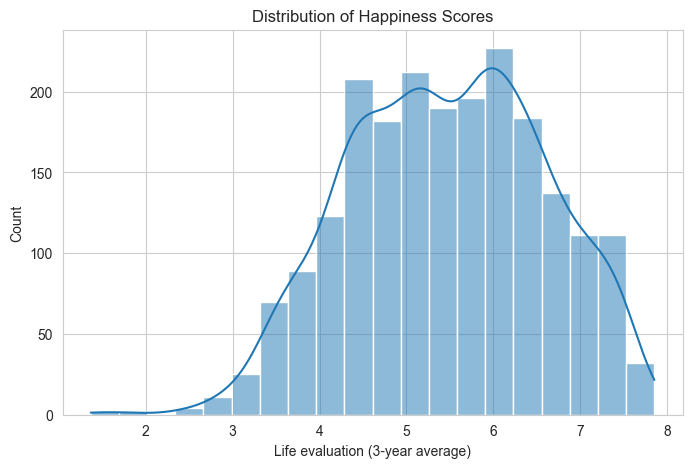

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Life evaluation (3-year average)"],
    bins=20,
    kde=True
)

plt.title("Distribution of Happiness Scores")
plt.show()

In [14]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

corr

,Year,Rank,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
Year,1.000000,-0.054687,0.069590,0.037644,0.039037,0.415666,0.290099,-0.077339,0.631789,-0.326119,0.046145,-0.525180
Rank,-0.054687,1.000000,-0.982802,-0.975496,-0.973429,-0.695154,-0.676425,-0.648545,-0.449211,-0.027162,-0.438400,-0.354564
Life evaluation (3-year average),0.069590,-0.982802,1.000000,0.999489,0.999458,0.681186,0.701408,0.659369,0.490965,0.035323,0.426265,0.378327
Lower whisker,0.037644,-0.975496,0.999489,1.000000,0.997895,0.686298,0.704323,0.668383,0.489952,0.033537,0.429506,0.369069
Upper whisker,0.039037,-0.973429,0.999458,0.997895,1.000000,0.675180,0.697651,0.649386,0.491482,0.037133,0.422486,0.387485
Explained by: Log GDP per capita,0.415666,-0.695154,0.681186,0.686298,0.675180,1.000000,0.629196,0.540046,0.489917,-0.248114,0.364336,-0.264734
Explained by: Social support,0.290099,-0.676425,0.701408,0.704323,0.697651,0.629196,1.000000,0.528869,0.502171,-0.101177,0.204128,-0.153834
Explained by: Healthy life expectancy,-0.077339,-0.648545,0.659369,0.668383,0.649386,0.540046,0.528869,1.000000,0.288303,-0.029045,0.355586,-0.042451
Explained by: Freedom to make life choices,0.631789,-0.449211,0.490965,0.489952,0.491482,0.489917,0.502171,0.288303,1.000000,-0.081213,0.282497,-0.241522
Explained by: Generosity,-0.326119,-0.027162,0.035323,0.033537,0.037133,-0.248114,-0.101177,-0.029045,-0.081213,1.000000,0.142618,0.169123


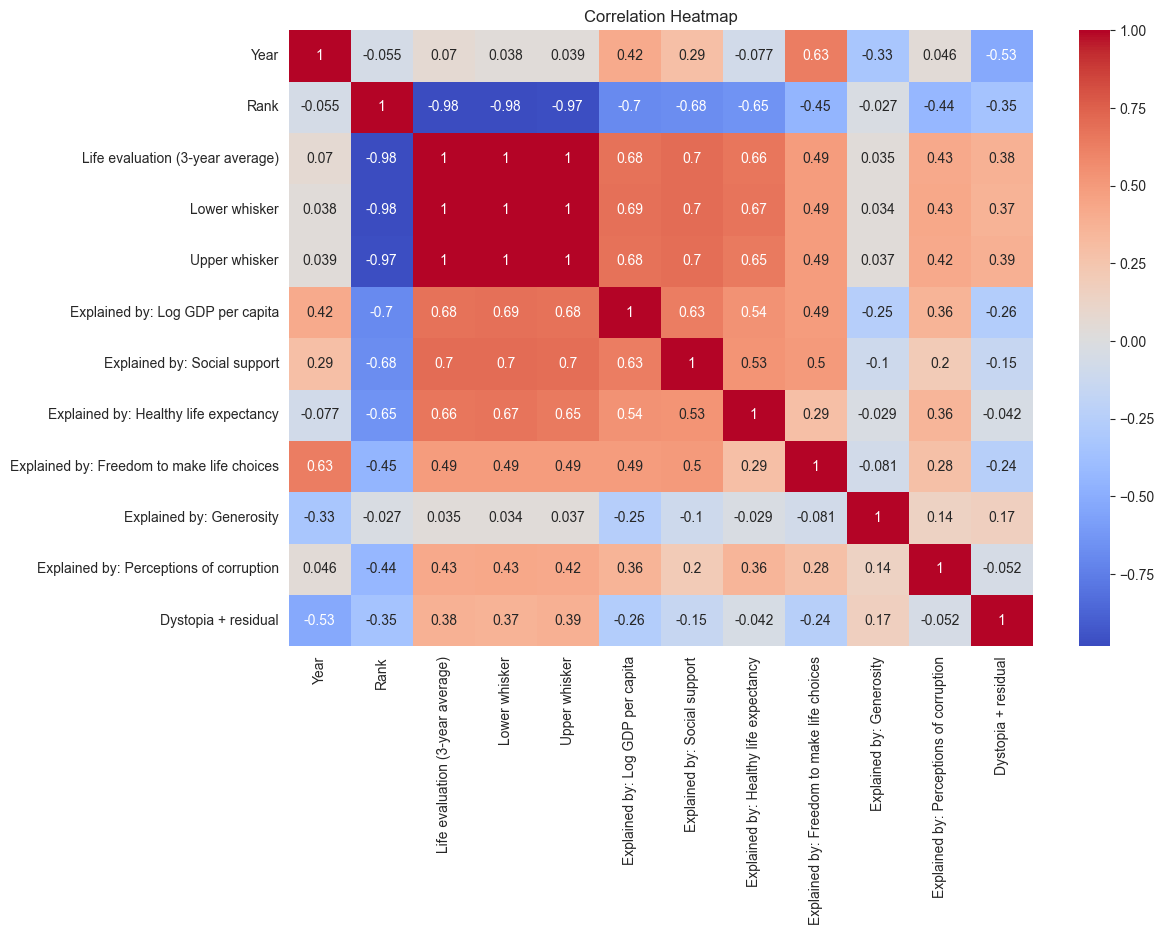

In [15]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

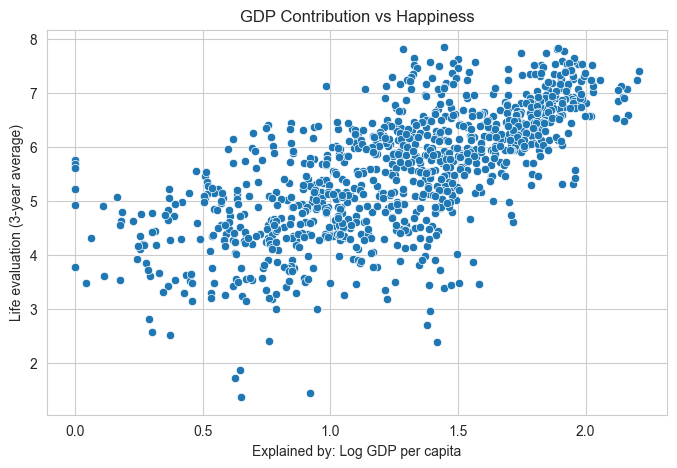

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Explained by: Log GDP per capita",
    y="Life evaluation (3-year average)"
)

plt.title("GDP Contribution vs Happiness")
plt.show()

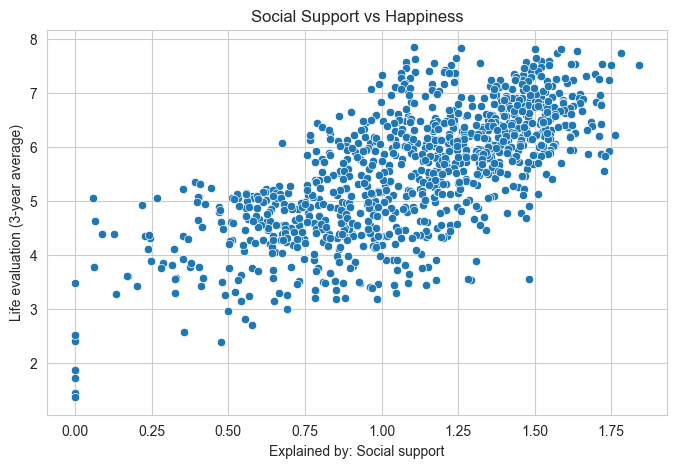

In [17]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Explained by: Social support",
    y="Life evaluation (3-year average)"
)

plt.title("Social Support vs Happiness")
plt.show()

In [18]:
yearly = df.groupby("Year")[
    "Life evaluation (3-year average)"
].mean()

yearly

Year
2011    5.391538
2012    5.418731
2014    5.375741
2015    5.382185
2016    5.354019
2017    5.375878
2018    5.407096
2019    5.473240
2020    5.532839
2021    5.553575
2022    5.539796
2023    5.527580
2024    5.578170
2025    5.649857
Name: Life evaluation (3-year average), dtype: float64

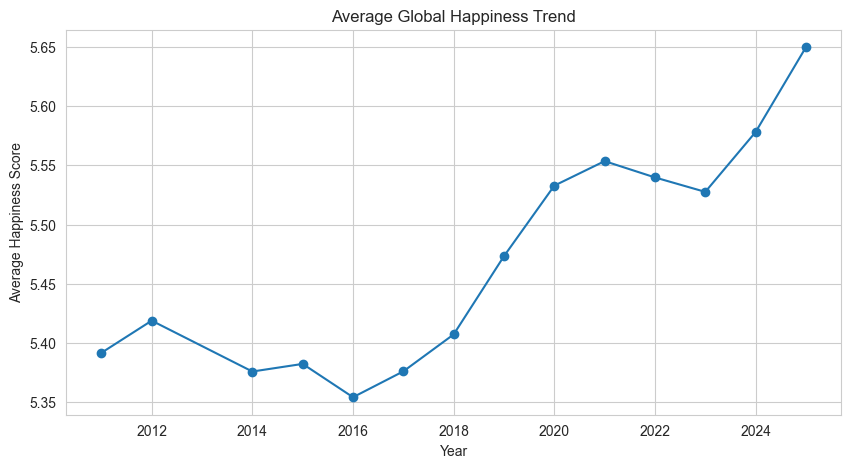

In [19]:
plt.figure(figsize=(10,5))

plt.plot(
    yearly.index,
    yearly.values,
    marker="o"
)

plt.title("Average Global Happiness Trend")
plt.xlabel("Year")
plt.ylabel("Average Happiness Score")

plt.show()

In [20]:
features = [
    "Explained by: Log GDP per capita",
    "Explained by: Social support",
    "Explained by: Healthy life expectancy",
    "Explained by: Freedom to make life choices",
    "Explained by: Generosity",
    "Explained by: Perceptions of corruption",
    "Dystopia + residual"
]

correlation = df[features + [
    "Life evaluation (3-year average)"
]].corr()

correlation["Life evaluation (3-year average)"].sort_values(
    ascending=False
)

Life evaluation (3-year average)              1.000000
Explained by: Social support                  0.701408
Explained by: Log GDP per capita              0.681186
Explained by: Healthy life expectancy         0.659369
Explained by: Freedom to make life choices    0.490965
Explained by: Perceptions of corruption       0.426265
Dystopia + residual                           0.378327
Explained by: Generosity                      0.035323
Name: Life evaluation (3-year average), dtype: float64